## Исследование НС с радиальными базисными функциями (RBF) на примере моделирования булевых выражений

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product, combinations
from typing import List, Tuple

In [137]:
def func(x1: int, x2: int, x3: int, x4: int) -> int:
    return int(not(((x1 or x2) and x3) or (x3 and x4)))


def get_truth_table(func):
    values = list(list(x) + [func(*x)] for x in product([0, 1], repeat=func.__code__.co_argcount))
    df = pd.DataFrame(values, columns=(list(func.__code__.co_varnames) + [func.__name__]))
    return df

### Таблица истинности функции

In [138]:
truth_table = get_truth_table(func)
truth_table

,x1,x2,x3,x4,func
0,0,0,0,0,1
1,0,0,0,1,1
2,0,0,1,0,1
3,0,0,1,1,0
4,0,1,0,0,1
5,0,1,0,1,1
6,0,1,1,0,0
7,0,1,1,1,0
8,1,0,0,0,1
9,1,0,0,1,1


### Определим центры RBF

In [139]:
def get_centers(func) -> np.ndarray:
    truth_table = get_truth_table(func)
    J0 = truth_table[truth_table['func'] == 0].values[:, : -1]
    J1 = truth_table[truth_table['func'] == 1].values[:, : -1]
    centers = J0 if len(J0) <= len(J1) else J1
    return centers


### Класс RBF НС

In [140]:
class RBF_Neuron:
    def __init__(self, centers: List[np.ndarray], learning_rate: float = 0.3, activation_type: str = 'threshold'):
        self.centers = np.array(centers)          
        self.J = len(centers)                      
        self.weights = np.zeros(self.J + 1)        
        self.learning_rate = learning_rate
        self.activation_type = activation_type
        self.delta_history = []
        self.last_epoch = -1
        self.weights_history = []

    def get_phi(self, X: np.ndarray) -> np.ndarray:
        phi = []
        for j in range(self.J):
            diff = X - self.centers[j]
            phi.append(np.exp(-np.sum(diff**2)))
        return np.array(phi)

    def get_net(self, phi: np.ndarray) -> float:
        return np.dot(self.weights[1:], phi) + self.weights[0]


    def activate(self, net: float) -> float:
        if self.activation_type == 'threshold':
            return 1.0 if net >= 0.0 else 0.0
        elif self.activation_type == 'logistic':
            return 0.5 * (np.tanh(net) + 1)
        else:
            raise ValueError(f'Неизвестная функция активации -> {self.activation_type}')


    def predict(self, X_i: np.ndarray) -> int:
        phi = self.get_phi(X_i)
        net = self.get_net(phi)
        out = self.activate(net)
        if self.activation_type == 'logistic':
            return 1 if out >= 0.5 else 0
        return int(out)


    def predict_batch(self, X: np.ndarray) -> np.ndarray:
        return np.array([self.predict(x) for x in X])


    def train_step(self, X: np.ndarray, target: int) -> float:
        phi = self.get_phi(X)
        net = self.get_net(phi)
        y_pred = self.activate(net)
        delta = target - y_pred
        if self.activation_type == 'threshold':
            self.weights[1:] += self.learning_rate * delta * phi
            self.weights[0] += self.learning_rate * delta
        else:
            out = self.activate(net)
            df_net = 2 * out * (1 - out)
            self.weights[1:] += self.learning_rate * delta * phi * df_net
            self.weights[0] += self.learning_rate * delta * df_net
        return abs(delta)


    def train_epoch(self, X: np.ndarray, y: np.ndarray) -> float:
        total_delta = 0
        for i in range(len(X)):
            delta = self.train_step(X[i], y[i])
            total_delta += delta
        return total_delta


    def train(self, X: np.ndarray, y: np.ndarray, X_full, y_full, max_epochs: int = 1000) -> List[float]:
        self.targets = y.copy()
        self.delta_history = []
        for epoch in range(max_epochs):
            self.train_epoch(X, y)
            self.weights_history.append(self.weights.copy())
            y_pred_full = self.predict_batch(X_full)
            full_error = np.sum(y_pred_full != y_full)
            self.delta_history.append(full_error)
            if full_error == 0:
                self.last_epoch = epoch + 1
                break
        else:
            self.last_epoch = max_epochs
        return self.delta_history
    
    
    def print_training_info(self, X: np.ndarray) -> None:
        print(f"\n{'='*50}")
        print(f'Информация о RBF нейроне с {"пороговой" if self.activation_type == "threshold" else "логистической"} ФА')
        print(f'Скорость обучения -> {self.learning_rate}')
        print(f'Образцов -> {len(X)}')
        print(f'Веса -> {self.weights}')
        if self.last_epoch > -1:
            print(f'Обучение завершено на эпохе -> {self.last_epoch}')
        else:
            print(f'Обучение ещё не проводилось или не было успешно завершено')
        print(f"{'='*50}\n")


    def get_truth_table_results(self, X: np.ndarray) -> pd.DataFrame:
        df = pd.DataFrame(X, columns=['x1', 'x2', 'x3', 'x4'])
        df['target'] = self.targets
        df['predicted'] = self.predict_batch(X)
        df['match'] = df['target'] == df['predicted']
        return df
    
    
    def get_weights_history(self) -> pd.DataFrame:
        if not self.weights_history:
            return pd.DataFrame()
        weight_cols = [f'w{i}' for i in range(len(self.weights))]
        df = pd.DataFrame(self.weights_history, columns=weight_cols)
        df['epoch'] = range(1, len(df) + 1)
        df['E(epoch)'] = self.delta_history
        cols = ['epoch'] + weight_cols + ['E(epoch)']
        return df[cols]

In [141]:
def get_plot(threshold_deltas: List[float], logistic_deltas: List[float]) -> None:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    last_epoch_threshold = len(threshold_deltas)
    last_epoch_logistic = len(logistic_deltas)
    
    all_epochs_threshold = list(range(1, last_epoch_threshold + 1))
    ax1_ticks = all_epochs_threshold[::max(1, len(all_epochs_threshold) // 10)]
    if last_epoch_threshold not in ax1_ticks:
        ax1_ticks = sorted(ax1_ticks + [last_epoch_threshold])

    all_epochs_logistic = list(range(1, last_epoch_logistic + 1))
    ax2_ticks = all_epochs_logistic[::max(1, len(all_epochs_logistic) // 10)]
    if last_epoch_logistic not in ax2_ticks:
        ax2_ticks = sorted(ax2_ticks + [last_epoch_logistic])
    
    ax1.plot(
        range(1, last_epoch_threshold + 1),
        threshold_deltas,
        marker='o',
        label='Пороговая ФА'
        )
    ax1.scatter(last_epoch_threshold, threshold_deltas[-1], 
                color='red', s=100, zorder=5, label='Последняя эпоха')
    ax1.axvline(x=last_epoch_threshold, color='red', linestyle='--', 
                alpha=0.7, linewidth=1)
    ax1.set_xlabel('Эпоха k', fontsize=14)
    ax1.set_ylabel('Суммарная ошибка E(k)', fontsize=14)
    ax1.set_title('Динамика обучения перцептрона (Пороговая ФА)', fontsize=16, pad=10)
    ax1.set_xticks(ax1_ticks)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.5, linestyle='--')
    ax1.set_ylim(bottom=0)
    
    ax2.plot(
        range(1, last_epoch_logistic + 1),
        logistic_deltas,
        marker='o',
        label='Логистическая ФА'
        )
    ax2.scatter(last_epoch_logistic, logistic_deltas[-1], 
                color='red', s=100, zorder=5, label='Последняя эпоха')
    ax2.axvline(x=last_epoch_logistic, color='red', linestyle='--', 
                alpha=0.7, linewidth=1)
    ax2.set_xticks(ax2_ticks)
    ax2.set_xlabel('Эпоха k', fontsize=14)
    ax2.set_ylabel('Суммарная ошибка E(k)', fontsize=14)
    ax2.set_title('Динамика обучения перцептрона (Логистическая ФА)', fontsize=16, pad=10)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.5, linestyle='--')
    ax2.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.show()

### Тренируем перцептроны с пороговой и логистической ФА


Информация о RBF нейроне с пороговой ФА
Скорость обучения -> 0.3
Образцов -> 16
Веса -> [ 0.9        -0.50367585 -0.36492007 -0.44574565 -0.40002597 -0.54117336
 -0.54939554 -0.31670542]
Обучение завершено на эпохе -> 12

    x1  x2  x3  x4  target  predicted  match
0    0   0   0   0       1          1   True
1    0   0   0   1       1          1   True
2    0   0   1   0       1          1   True
3    0   0   1   1       0          0   True
4    0   1   0   0       1          1   True
5    0   1   0   1       1          1   True
6    0   1   1   0       0          0   True
7    0   1   1   1       0          0   True
8    1   0   0   0       1          1   True
9    1   0   0   1       1          1   True
10   1   0   1   0       0          0   True
11   1   0   1   1       0          0   True
12   1   1   0   0       1          1   True
13   1   1   0   1       1          1   True
14   1   1   1   0       0          0   True
15   1   1   1   1       0          0   True

    epoch  

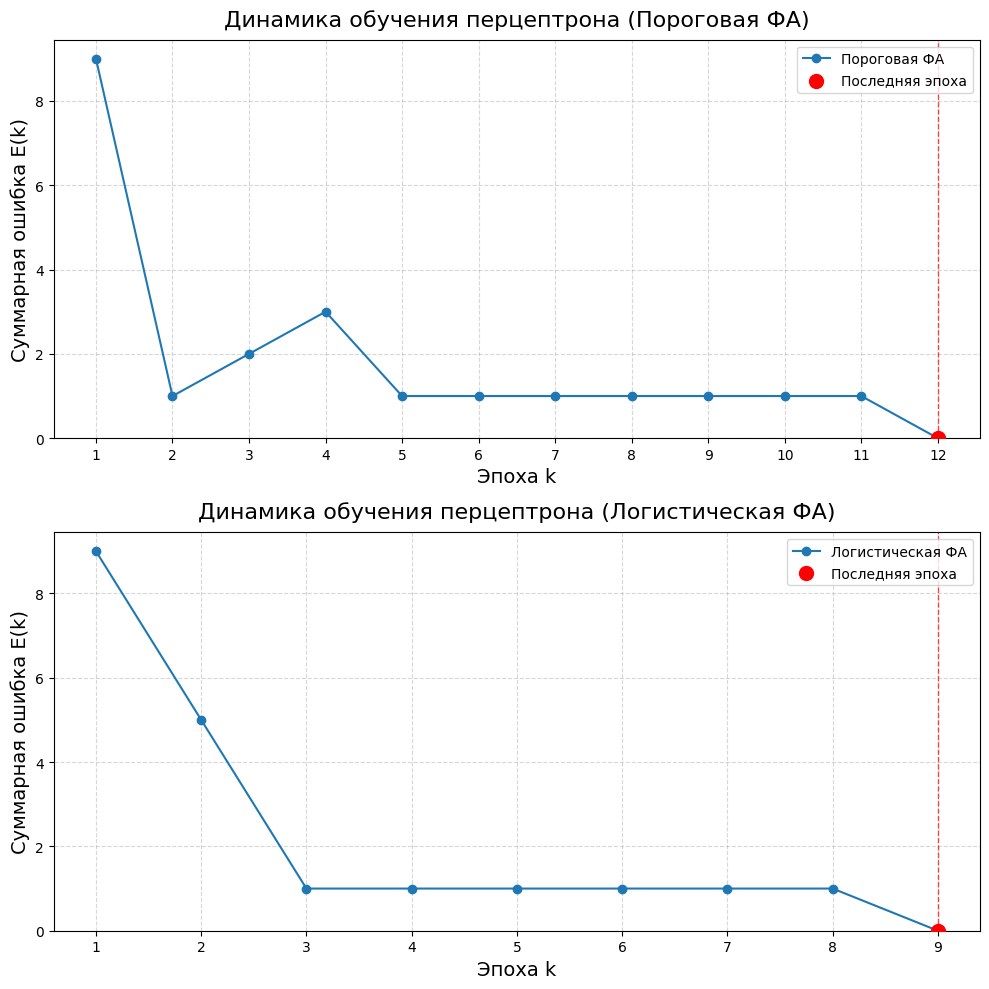

In [142]:
rbf_centers = get_centers(func)
X = np.array(truth_table.drop(columns='func').values.tolist())
y = np.array(truth_table['func'].values.tolist())

threshold_neuron = RBF_Neuron(rbf_centers, activation_type='threshold')
threshold_deltas = threshold_neuron.train(X, y, X_full=X, y_full=y)
threshold_neuron.print_training_info(X)
threshold_truth_table = threshold_neuron.get_truth_table_results(X)
threshold_weights_deltas_history = threshold_neuron.get_weights_history()
print(f'{threshold_truth_table}\n')
print(threshold_weights_deltas_history)

logistic_neuron = RBF_Neuron(rbf_centers, activation_type='logistic')
logistic_deltas = logistic_neuron.train(X, y, X_full=X, y_full=y)
logistic_neuron.print_training_info(X)
logistic_truth_table = logistic_neuron.get_truth_table_results(X)
logistic_weights_deltas_history = logistic_neuron.get_weights_history()
print(logistic_truth_table)
print(logistic_weights_deltas_history)

get_plot(threshold_deltas, logistic_deltas)

### Найдем минимальный обучающий вектор

In [143]:
def find_minimal_set_rbf(
    X: np.ndarray, 
    y: np.ndarray, 
    centers: np.ndarray,
    learning_rate: float = 0.3,
    activation_type: str = 'threshold'
) -> Tuple[RBF_Neuron, pd.DataFrame, List]:
    n_samples = len(X)
    min_size = len(centers)
    for size in range(min_size, n_samples + 1):
        print(f"Проверка подмножеств размера {size}...")
        for idx in combinations(range(n_samples), size):
            idx = list(idx)
            X_sub = X[idx]
            y_sub = y[idx]
            
            neuron = RBF_Neuron(
                centers=centers, 
                learning_rate=learning_rate,
                activation_type=activation_type
            )
            delta_history = neuron.train(
                X=X_sub, y=y_sub,
                X_full=X, y_full=y,
                max_epochs=1000
            )
            
            if neuron.last_epoch < 1000:
                df = pd.DataFrame(X_sub, columns=['x1', 'x2', 'x3', 'x4'])
                df['target'] = y_sub
                print(f"Нашли, Размер: {size}, эпох: {neuron.last_epoch}")
                return neuron, df, delta_history
    
    print('Не найдено решение')
    return None, None, None

Проверка подмножеств размера 7...
Нашли, Размер: 7, эпох: 12

Информация о RBF нейроне с пороговой ФА
Скорость обучения -> 0.3
Образцов -> 16
Веса -> [ 0.9        -0.38936528 -0.48479299 -0.55016625 -0.416249   -0.52495033
 -0.56005622 -0.34281843]
Обучение завершено на эпохе -> 12

   x1  x2  x3  x4  target
0   0   0   0   0       1
1   0   0   0   1       1
2   0   0   1   0       1
3   0   0   1   1       0
4   0   1   0   0       1
5   0   1   1   0       0
6   1   0   1   0       0
    epoch   w0        w1        w2        w3        w4        w5        w6  \
0       1 -0.3 -0.325664 -0.230237 -0.180127 -0.066265 -0.119805 -0.084699   
1       2  0.0 -0.500365 -0.404937 -0.304717 -0.076993 -0.184074 -0.148968   
2       3  0.0 -0.690001 -0.335174 -0.374481 -0.266630 -0.349265 -0.218731   
3       4  0.3 -0.579637 -0.320237 -0.333880 -0.511093 -0.404092 -0.308664   
4       5  0.6 -0.658909 -0.235538 -0.363043 -0.426393 -0.433255 -0.277505   
5       6  0.6 -0.589146 -0.425174 -0.43

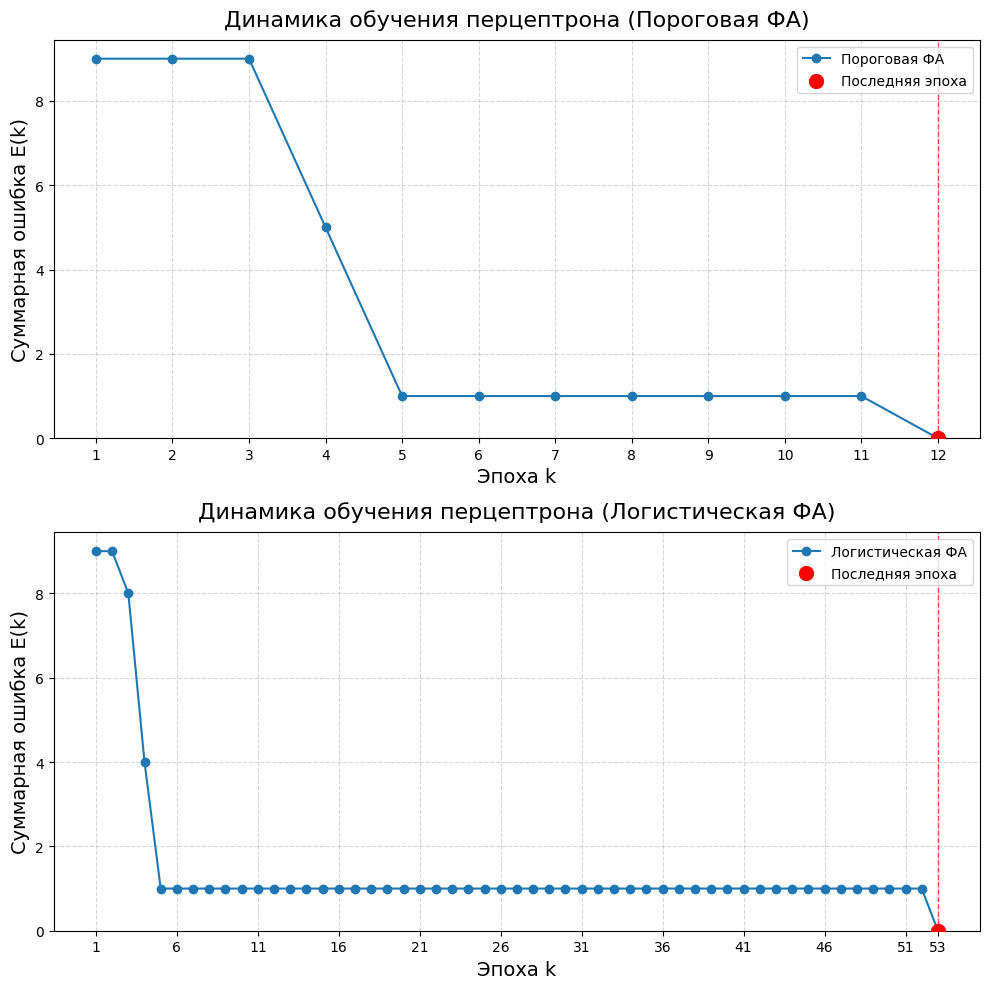

In [144]:
rbf_centers = get_centers(func)


X = np.array(truth_table.drop('func', axis=1).values)
y = np.array(truth_table['func'].values)


neuron_thresh, df_thresh, history_thresh = find_minimal_set_rbf(
    X, y, rbf_centers, 
    learning_rate=0.3, 
    activation_type='threshold'
)
neuron_thresh.print_training_info(X)
threshold_weights_deltas_history = neuron_thresh.get_weights_history()
print(df_thresh)
print(threshold_weights_deltas_history)


neuron_log, df_log, history_log = find_minimal_set_rbf(
    X, y, rbf_centers, 
    learning_rate=0.3, 
    activation_type='logistic'
)
neuron_log.print_training_info(X)
log_weights_deltas_history = neuron_log.get_weights_history()
print(df_log)
print(log_weights_deltas_history)


get_plot(history_thresh, history_log)